# iSmart2 on PYNQ-Z1 — 单图上板验证

目标：验证自建 bitstream 在真实硬件上可加载、IP 可响应、能输出 bounding box。

相对原版 notebook 的改动：
1. 权重数组 shape 改为 405 / 22 / 67（依据 `net_hls.h` 顶层函数声明，与自建 bitstream 配套）
2. `Xlnk` 改为 `pynq.allocate`（PYNQ v2.7 起移除 Xlnk）
3. 去掉 DAC 竞赛框架依赖（`preprocessing.Agent`、`get_image_batch`），改为单张图片

寄存器地址依据：`xmobilenet_hw.h`

In [28]:
import numpy as np
import time
from PIL import Image
import matplotlib.pyplot as plt
from pynq import Overlay, allocate

BASE = '/home/xilinx/jupyter_notebooks/iSmart2/'
BIT  = BASE + 'iSmart2.bit'
WGT  = BASE + 'iSmart2.bin'
IMG  = BASE + 'test.jpg'

# 寄存器偏移（xmobilenet_hw.h）
R_CTRL = 0x00
R_IMG  = 0x10
R_W1X1 = 0x18
R_W3X3 = 0x20
R_BIAS = 0x28
R_P3   = 0x30
R_P6   = 0x38
R_BUF  = 0x40
R_BOX  = 0x48

print('imports ok')

imports ok


## 1. 加载 overlay

In [29]:
overlay = Overlay(BIT)
print('bitstream loaded')
print(list(overlay.ip_dict.keys()))   # 确认 IP 实例名
myIP = overlay.mobilenet_0

bitstream loaded
['mobilenet_0', 'processing_system7_0']


## 2. 分配连续物理内存

`allocate` 申请的是物理连续、可被 FPGA 通过 AXI 主接口直接访问的内存（DMA 不经过 MMU，拿不到散列的虚拟页）。
`.physical_address` 就是写进 IP 寄存器的那个地址。

In [30]:
img   = allocate(shape=(3, 162, 322), dtype=np.uint8)

w1x1  = allocate(shape=(405, 16, 16),    dtype=np.uint16)
w3x3  = allocate(shape=(22, 16, 3, 3),   dtype=np.uint16)
bias  = allocate(shape=(67, 16),         dtype=np.uint16)

pool3 = allocate(shape=(48, 82, 162),    dtype=np.uint16)
pool6 = allocate(shape=(96, 42, 82),     dtype=np.uint16)
buf   = allocate(shape=(36, 16, 22, 42), dtype=np.uint16)
box   = allocate(shape=(5,),             dtype=np.float32)

print('allocated')
print('need uint16:', w1x1.size + w3x3.size + bias.size)

allocated
need uint16: 107920


## 3. 载入权重

`iSmart2.bin` 由 `reorder_weight_fix()` 生成，写入顺序：1x1 权重 → 3x3 权重 → bias。

In [31]:
params = np.fromfile(WGT, dtype=np.uint16)
print('file uint16:', params.size, '  expect:', w1x1.size + w3x3.size + bias.size)

i = 0
np.copyto(w1x1, params[i:i+w1x1.size].reshape(w1x1.shape));  i += w1x1.size
np.copyto(w3x3, params[i:i+w3x3.size].reshape(w3x3.shape));  i += w3x3.size
np.copyto(bias, params[i:i+bias.size].reshape(bias.shape));  i += bias.size
print('consumed:', i)

file uint16: 107920   expect: 107920
consumed: 107920


## 4. 预处理图片

原版流程：resize 到 320×160 → 贴进 322×162 的灰底（四周 padding 127）→ HWC 转 CHW。

original size: (640, 360)


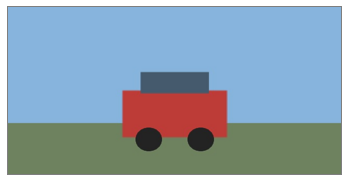

In [32]:
raw = Image.open(IMG).convert('RGB')
print('original size:', raw.size)

blank = Image.new('RGB', (322, 162), (127, 127, 127))
blank.paste(raw.resize((320, 160)), (1, 1))
np.copyto(img, np.transpose(np.array(blank), (2, 0, 1)))

plt.imshow(blank); plt.axis('off'); plt.show()

## 5. 写地址寄存器

In [33]:
myIP.write(R_IMG,  img.physical_address)
myIP.write(R_W1X1, w1x1.physical_address)
myIP.write(R_W3X3, w3x3.physical_address)
myIP.write(R_BIAS, bias.physical_address)
myIP.write(R_P3,   pool3.physical_address)
myIP.write(R_P6,   pool6.physical_address)
myIP.write(R_BUF,  buf.physical_address)
myIP.write(R_BOX,  box.physical_address)

print('ctrl before start: 0x%02x' % myIP.read(R_CTRL))

ctrl before start: 0x04


## 6. 启动并等待

`ap_ctrl` 的 bit0 = ap_start（写 1 启动），bit1 = ap_done。
原版 notebook 用 `read(0x00) == 1` 轮询，这里加超时，避免 IP 不响应时 kernel 卡死。

In [34]:
t0 = time.time()
myIP.write(R_CTRL, 1)

TIMEOUT = 10.0
while myIP.read(R_CTRL) & 0x1:
    if time.time() - t0 > TIMEOUT:
        raise RuntimeError('IP timeout, ctrl=0x%02x' % myIP.read(R_CTRL))
    time.sleep(0.001)

dt = time.time() - t0
print('done in %.1f ms  ->  %.1f FPS' % (dt * 1000, 1 / dt))
print('ctrl after: 0x%02x' % myIP.read(R_CTRL))
print('raw predict_box:', np.array(box))

done in 198.7 ms  ->  5.0 FPS
ctrl after: 0x04
raw predict_box: [0.        0.5       1.4940052 2.359848  0.5      ]


## 7. 解码 bounding box

原版的换算：box[0]/40、box[1]/20、box[2]/40、box[3]/20 得到归一化的中心点与宽高，
再按原始图 640×360 还原成像素坐标。

box (x1,y1,x2,y2) = (-12, -12, 12, 30)


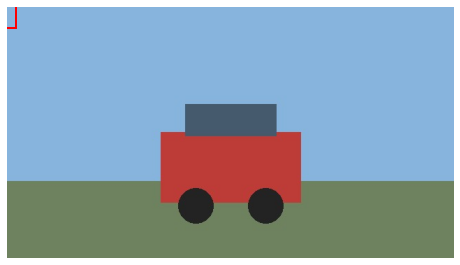

In [35]:
b = np.array(box, dtype=np.float32)
cx, cy, w, h = b[0]/40, b[1]/20, b[2]/40, b[3]/20

W, H = raw.size
x1 = int(round((cx - w/2) * W));  y1 = int(round((cy - h/2) * H))
x2 = int(round((cx + w/2) * W));  y2 = int(round((cy + h/2) * H))
print('box (x1,y1,x2,y2) =', (x1, y1, x2, y2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.imshow(raw)
ax.add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                           fill=False, edgecolor='red', linewidth=2))
ax.axis('off'); plt.show()

## 8. 释放内存

In [36]:
for a in (img, w1x1, w3x3, bias, pool3, pool6, buf, box):
    a.freebuffer()
print('freed')

freed
